<div align="center">


# CSE-422 PROJECT REPORT

## PREDICTIVE MODELING AND ANALYSIS FOR DEPRESSION RISK USING MACHINE LEARNING TECHNIQUES

</div>

---

**Semester:** Summer 2026

**Submitted By:**
* **Name:** Utsho Heaven Chowdhury | **Student ID:** 21201574
* **Name:** Utsho Heaven Chowdhury | **Student ID:** 21201574


**Section:** 09 | **Group:** 


**Submission Date:** [Date]

---










## 1. Introduction

### 1.1 Project Aim
This project aims to develop and evaluate predictive machine learning models capable of classifying the risk and severity of depression in individuals. By analyzing demographic details, academic metrics, and responses to psychometric questionnaires, the project seeks to build an automated diagnostic tool using both supervised algorithms and unsupervised clustering techniques.

### 1.2 Problem Statement
Depression is frequently underdiagnosed or detected late due to social stigma, limited access to mental health professionals, and a heavy reliance on manual, subjective screening processes. Traditional diagnostic workflows are resource-intensive and lack the scalability required for broad, early-warning detection. The technical challenge is to identify distinct risk patterns and accurately classify individuals while minimizing false negatives in the dataset.

### 1.3 Motivation
Mental health disorders are a leading cause of global health burdens, severely impacting personal well-being, academic performance, and overall quality of life. The motivation behind this project is to leverage machine learning to discover complex relationships between academic pressure, behavioral habits, and mental state. An automated predictive model can serve as an early-intervention aid for counselors and healthcare providers, helping to identify high-risk individuals before severe clinical escalation occurs.

In [17]:

%pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset 
df = pd.read_csv("Depression Data.csv")

# Display dataset info
df.info()

Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype
---  ------                                                                                                                                                                 --------------  -----
 0   1. Age                                                                                                                                                                 1977 non-null   str  
 1   2. Gender                                                                                                                                                              1971 non-null   str  
 2   5. Academic Year                                         


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Dataset Description & Exploratory Data Analysis (EDA)

### Dataset Description

* 
  There are a total of 37 features (columns) in the dataset, which include the input attributes and the target variable.

* This is a **classification** problem. The target variable we aim to predict is `Depression Label`. Because this target consists of distinct, discrete categories (e.g., different severity levels of depression) rather than a continuous numerical value, supervised classification algorithms are the appropriate approach.

* The dataset contains **1,977** data points (rows).

* The dataset contains a mix of both types:
  * **Quantitative:** 29 features are numerical, representing ordinal responses to psychological questionnaires and aggregated assessment scores.
  * **Categorical:** 8 features are categorical, representing demographic and academic information. 

* The categorical variables must be encoded. Machine learning algorithms (such as K-Nearest Neighbors, Logistic Regression, and Neural Networks) rely on mathematical equations and distance calculations to learn patterns. These models cannot process raw text or string data, so categorical features must be transformed into numerical formats using techniques like `Label Encoding` or `One-Hot Encoding`.

* **Correlation of all the features (apply heatmap using the seaborn library)**
  *(See the generated correlation heatmap below)*

*  
  Based on the correlation heatmap, several key insights emerge regarding the relationships between the features:
  * **Grouped questions are strongly linked:** Dark red blocks show that questions on the same topic (like anxiety) are highly correlated. High scores on one usually mean high scores on the rest.
  * **Stress, Anxiety, and Depression are connected:** Red areas linking the total scores show that students with high academic stress or anxiety also tend to have higher depression scores.
  * **Confidence lowers depression (Negative Correlation):** Blue areas highlight an opposite relationship. As a student's confidence and sense of control increase, their stress and depression scores decrease.

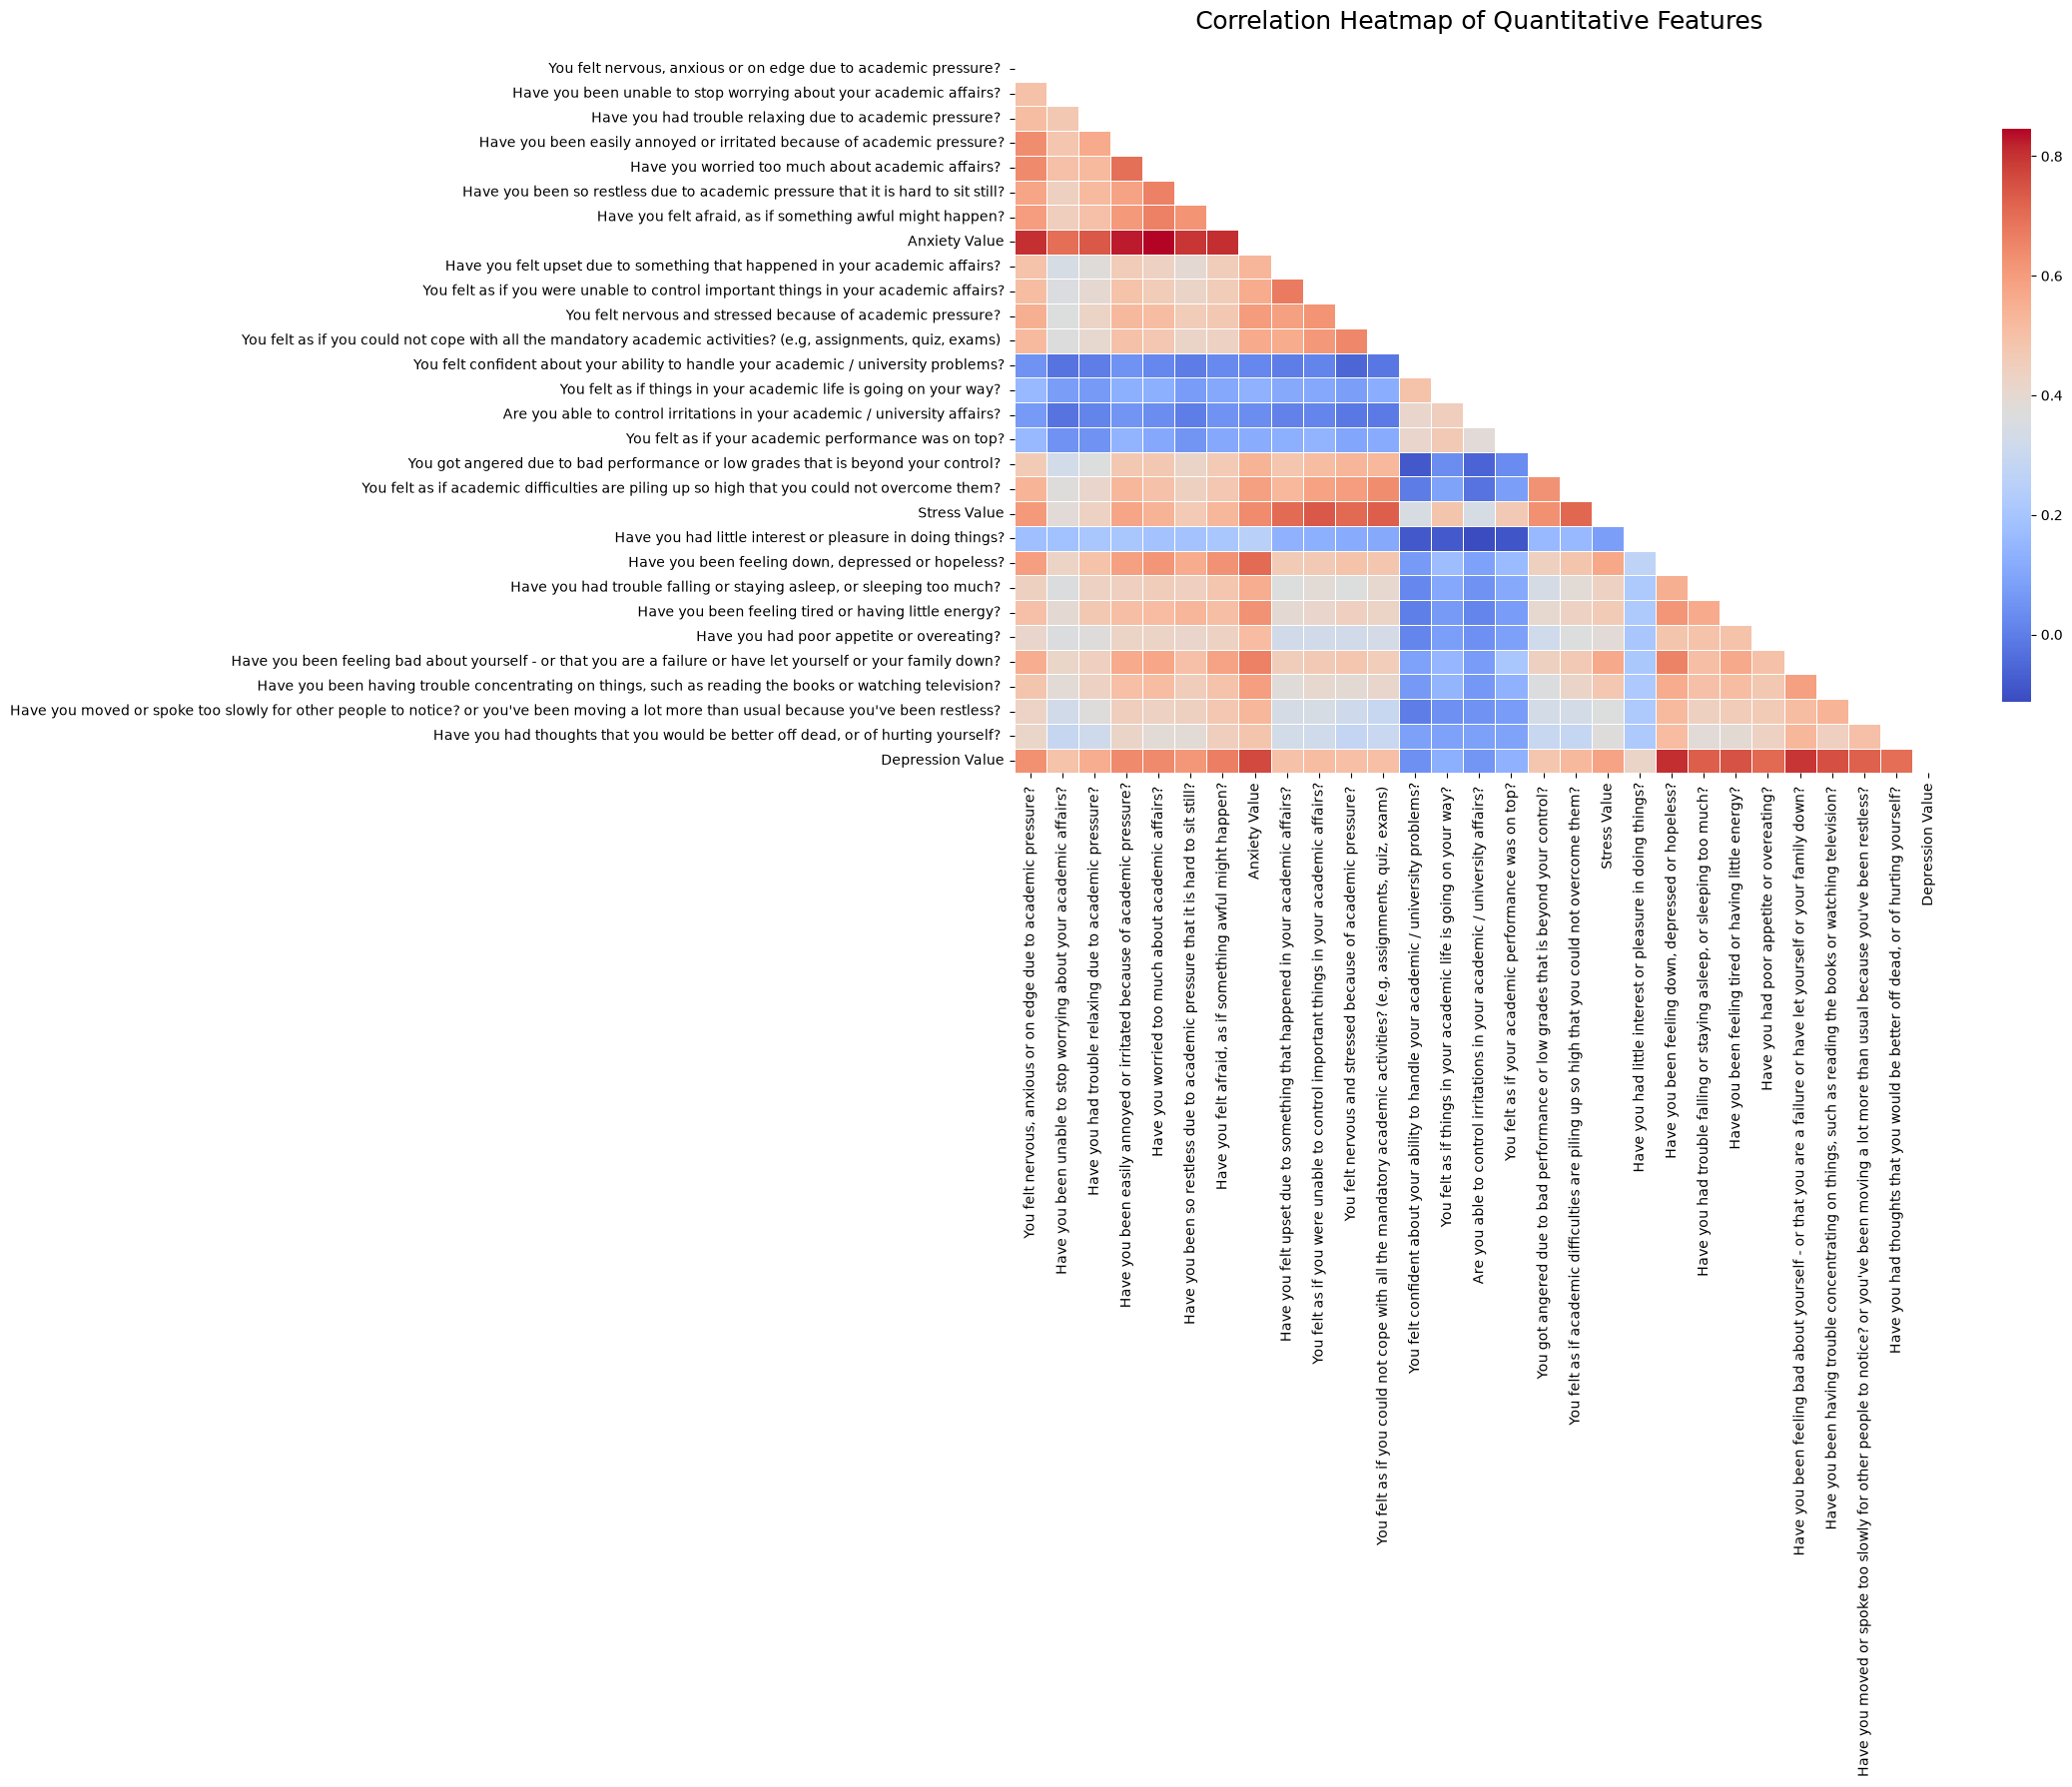

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter only quantitative (numerical) columns
numeric_df = df.select_dtypes(include=['int64'])

# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 3. Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Clean the labels by removing the repetitive prefix
clean_labels = []
for col in numeric_df.columns:
    if "how often " in col:
        # Keep everything after "how often "
        clean_name = col.split("how often ")[-1]
        # Capitalize the first letter to make it look clean
        clean_name = clean_name.capitalize()
        clean_labels.append(clean_name)
    else:
        clean_labels.append(col)

# 5. Set up the figure size (slightly wider to fit the text)
plt.figure(figsize=(22, 18))

# 6. Plot the cleaned heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            xticklabels=clean_labels, yticklabels=clean_labels, 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Quantitative Features', fontsize=18, pad=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

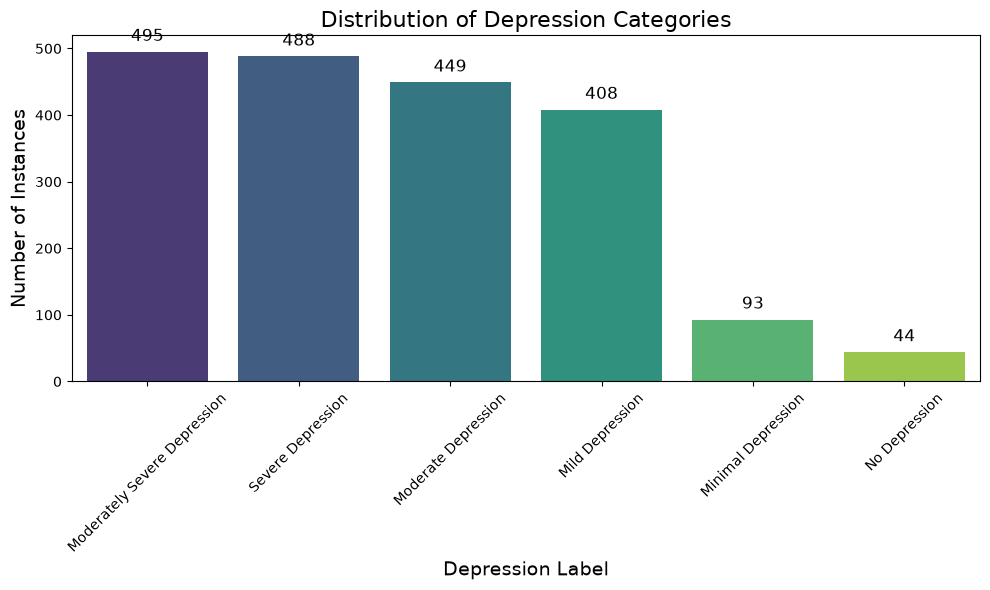

In [19]:
# Create the Bar Chart for the Target Variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Add counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories', fontsize=16)
plt.xlabel('Depression Label', fontsize=14)
plt.ylabel('Number of Instances', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Imbalanced Dataset

* The dataset is imbalanced. The target variable (`Depression Label`) does not have an equal distribution across its six classes. The majority of the instances are concentrated in the higher severity categories, with **Moderately Severe Depression** having the highest count (495 instances), followed closely by **Severe Depression** (488 instances). In contrast, the minority classes are drastically underrepresented, with **Minimal Depression** containing only 93 instances and **No Depression** containing just 44 instances. This imbalance means the model will train on far fewer examples of healthy individuals, which could bias predictions toward higher severity levels if not addressed during preprocessing.

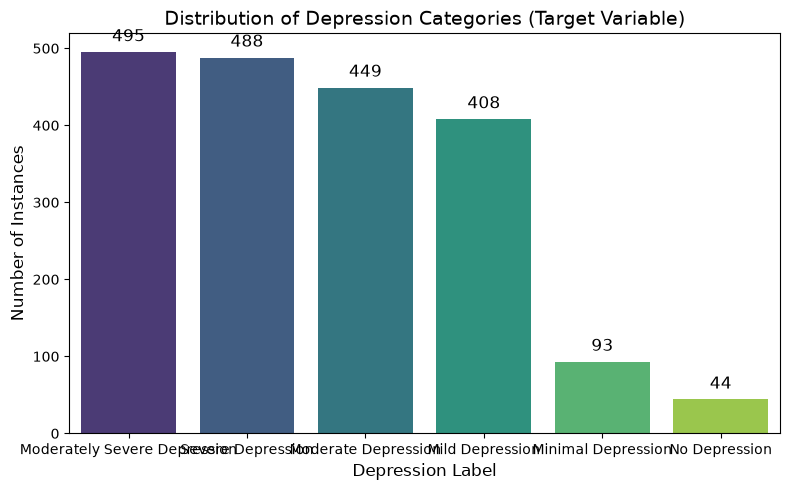


Exact counts for Imbalanced Dataset section:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


In [20]:
# ---------------------------------------------------------
# 1. Target Variable Distribution (To check for Imbalance)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Print the exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories (Target Variable)', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.tight_layout()
plt.show()

# Print the exact counts to fill in your report text
print("\nExact counts for Imbalanced Dataset section:")
print(df['Depression Label'].value_counts())

### Exploratory Data Analysis (EDA) - Important Relationships

To extract important relationships from the data, several exploratory visualizations were generated:

1. **Depression Severity vs. Stress Levels:** A boxplot analyzing the relationship between the `Aggregate Stress Value` and `Depression Label` shows a distinct upward trend. Individuals categorized with "Severe" or "Moderately Severe" depression consistently exhibit much higher median stress values (clustering between 20 and 30) compared to those with "Minimal" or "No Depression" (clustering below 20). This confirms that aggregate stress is a strong positive indicator of depression severity.
  *(Insert the "Relationship between Total Stress Value and Depression Severity" boxplot here)*

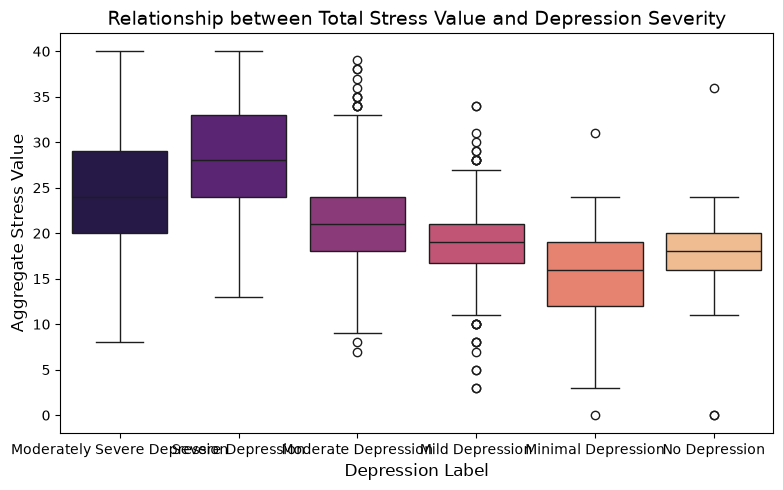

In [21]:
# ---------------------------------------------------------
# 2. EDA Relationship 1: Stress Value vs. Depression Label
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Depression Label', y='Stress Value', palette='magma', 
            order=df['Depression Label'].value_counts().index)
plt.title('Relationship between Total Stress Value and Depression Severity', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Aggregate Stress Value', fontsize=12)
plt.tight_layout()
plt.show()


2. **Depression Distribution by Gender:** A grouped bar chart reveals a significant gender disparity within the dataset. Across almost all depression categories—particularly Moderate, Moderately Severe, and Severe—the number of male instances is significantly higher than female instances. This indicates that gender is a highly influential demographic feature and highlights a specific demographic skew in the sampled population.

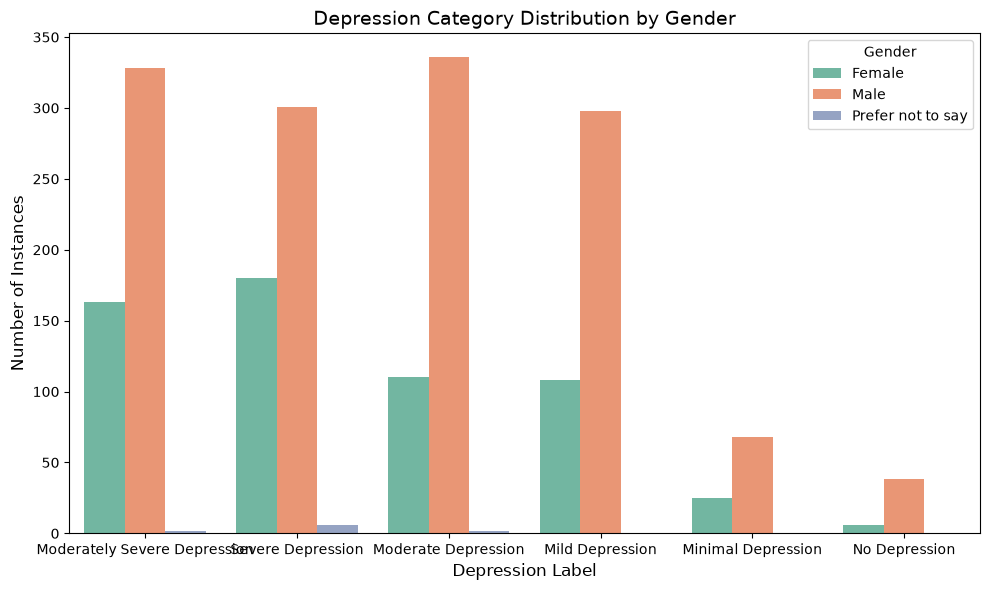

In [22]:
# ---------------------------------------------------------
# 3. EDA Relationship 2: Depression Label grouped by Gender
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Depression Label', hue='2. Gender', palette='Set2', 
              order=df['Depression Label'].value_counts().index)
plt.title('Depression Category Distribution by Gender', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 3. Dataset Pre-processing

### Problem 1: Null / Missing Values
Real-world datasets often contain incomplete data, which can cause algorithms to fail or produce biased results. Upon inspecting this dataset using `df.info()`, the `2. Gender` column was found to contain 6 missing (null) values out of the 1,977 total instances.
* **Solution Applied (Row Deletion):** Because 6 rows represent a statistically negligible fraction of the dataset (approximately 0.3%), imputing these values (e.g., using the mode) is unnecessary and could introduce synthetic bias. The most effective solution is to delete these 6 rows to ensure the model trains only on complete, authentic data.

### Problem 2: Categorical Values
Machine learning algorithms require numerical input to compute mathematical weights and distances. This dataset contains categorical features (stored as strings), including demographic data (`Age`, `Gender`, `Academic Year`) and the target variable (`Depression Label`).
* **Solution Applied (Label Encoding):** Label Encoding is applied to transform these textual categories into distinct integer values (e.g., converting "Male" and "Female" to 0 and 1). Because many of the categorical features inherently represent ordinal ranges (such as Age ranges or Academic Years), Label Encoding is a highly effective strategy that avoids unnecessarily expanding the dataset's dimensionality (which would happen if One-Hot Encoding were used).

### Problem 3: Feature Scaling
The numerical features in this dataset have varying ranges. For example, the individual psychological questions are scored on a standard Likert scale (1 to 5), while the aggregated columns (`Anxiety Value`, `Stress Value`, `Depression Value`) have much larger numerical ranges. Algorithms that rely on distance metrics (like KNN) will disproportionately weigh features with larger scales, leading to poor model performance.
* **Solution Applied (Min-Max Scaling):** To standardize the influence of all features, Min-Max Scaling (Normalization) is applied to the input features. This technique compresses all numerical values into a uniform range between 0 and 1 without distorting the underlying differences in the data.

In [23]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print(f"Original Dataset Shape: {df.shape}")
print(f"Missing values before processing: {df.isnull().sum().sum()}")

# ---------------------------------------------------------
# 1. Handling Missing Values (Deletion)
# ---------------------------------------------------------
# Drop rows with any null values
df_cleaned = df.dropna()
print(f"Dataset Shape after dropping nulls: {df_cleaned.shape}")

# ---------------------------------------------------------
# 2. Handling Categorical Values (Label Encoding)
# ---------------------------------------------------------
le = LabelEncoder()

# Select all categorical columns (type 'object')
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

print("\nSample of Encoded Categorical Data:")
print(df_cleaned[['1. Age', '2. Gender', 'Depression Label']].head(3))

# ---------------------------------------------------------
# 3. Feature Scaling (Min-Max Normalization)
# ---------------------------------------------------------
# Separate the target variable before scaling
X = df_cleaned.drop('Depression Label', axis=1)
y = df_cleaned['Depression Label']

scaler = MinMaxScaler()
# Fit and transform the features
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nSample of Scaled Features (Values now between 0.0 and 1.0):")
print(X_scaled[['Stress Value', 'Anxiety Value']].head(3))

Original Dataset Shape: (1977, 37)
Missing values before processing: 6
Dataset Shape after dropping nulls: (1971, 37)

Sample of Encoded Categorical Data:
   1. Age  2. Gender  Depression Label
0       0          0                 2
1       0          1                 0
2       0          1                 3

Sample of Scaled Features (Values now between 0.0 and 1.0):
   Stress Value  Anxiety Value
0         0.525       0.476190
1         0.450       0.428571
2         0.575       0.476190


## 4. Dataset Splitting

To evaluate the predictive models accurately, the pre-processed dataset is divided into a Training Set and a Testing Set. 
* **Split Ratio:** An 80/20 split is utilized, allocating 80% of the data to train the models and 20% to test their generalization on unseen data.
* **Splitting Strategy (Stratified):** As identified during the Exploratory Data Analysis, the target variable (`Depression Label`) is imbalanced. A standard random split could result in a testing set that lacks minority classes (e.g., "No Depression"). To solve this, **Stratified Sampling** is applied during the split. This guarantees that the exact class proportions of the original dataset are preserved across both the training and testing sets, ensuring fair and accurate model evaluation.

In [24]:
from sklearn.model_selection import train_test_split

# Perform the Stratified 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.20,      # 20% for testing, 80% for training
    random_state=42,     # Ensures reproducibility
    stratify=y           # Preserves class distribution
)

# Output the shapes of the resulting datasets
print("--- Dataset Splitting Summary ---")
print(f"Total instances: {X_scaled.shape[0]}")
print(f"Training Set (80%): {X_train.shape[0]} instances")
print(f"Testing Set (20%): {X_test.shape[0]} instances")

# Verify stratification worked on the Training Set
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True).round(3) * 100) # Shows percentage

--- Dataset Splitting Summary ---
Total instances: 1971
Training Set (80%): 1576 instances
Testing Set (20%): 395 instances

Class distribution in Training Set:
Depression Label
3    25.0
5    24.7
2    22.7
0    20.6
1     4.7
4     2.2
Name: proportion, dtype: float64


## 5. Model Training & Testing

This section addresses the problem using both supervised learning (for classification based on labeled data) and unsupervised learning (to discover hidden patterns without labels).

### 5.1 Supervised Learning (Classification)
To predict the specific `Depression Label`, three supervised machine learning algorithms were selected and trained on the 80% Training Set, then evaluated on the 20% Testing Set:

1. **Logistic Regression:** Selected as the baseline linear model for this classification task. It calculates the probability of an instance falling into a specific depression category and provides highly interpretable weights.
2. **Decision Tree Classifier:** Selected for its non-linear, rule-based approach. Decision trees operate similarly to a flowchart, naturally handling multi-class classification natively without requiring data transformation.
3. **Neural Network (Multi-Layer Perceptron):** A feedforward Artificial Neural Network (built via `sklearn.neural_network.MLPClassifier`) with two hidden layers (64 and 32 neurons) was selected to capture complex, non-linear relationships and interactions between the 29 different survey responses.

### 5.2 Unsupervised Learning (K-Means Clustering)
To explore the natural groupings within the dataset without relying on the predefined labels, the problem was also treated as an unsupervised learning task. 

* **Algorithm Applied:** The K-Means clustering algorithm was applied to the scaled feature set (excluding the target variable). The number of clusters ($K$) was explicitly set to 6 to see if the algorithm could naturally rediscover the 6 depression severity groupings based purely on the students' psychological and academic metrics.
* **Showcasing the Clusters:** Because the dataset contains 29 dimensions, **Principal Component Analysis (PCA)** was utilized to reduce the dimensionality down to 2 principal components. This allows the 6 clusters to be visually showcased on a 2D scatter plot.

Training Supervised Models...

--- Supervised Testing Set Accuracy ---
Logistic Regression Accuracy: 0.9038
Decision Tree Accuracy:       1.0000
Neural Network Accuracy:      0.9671

Applying K-Means Clustering...


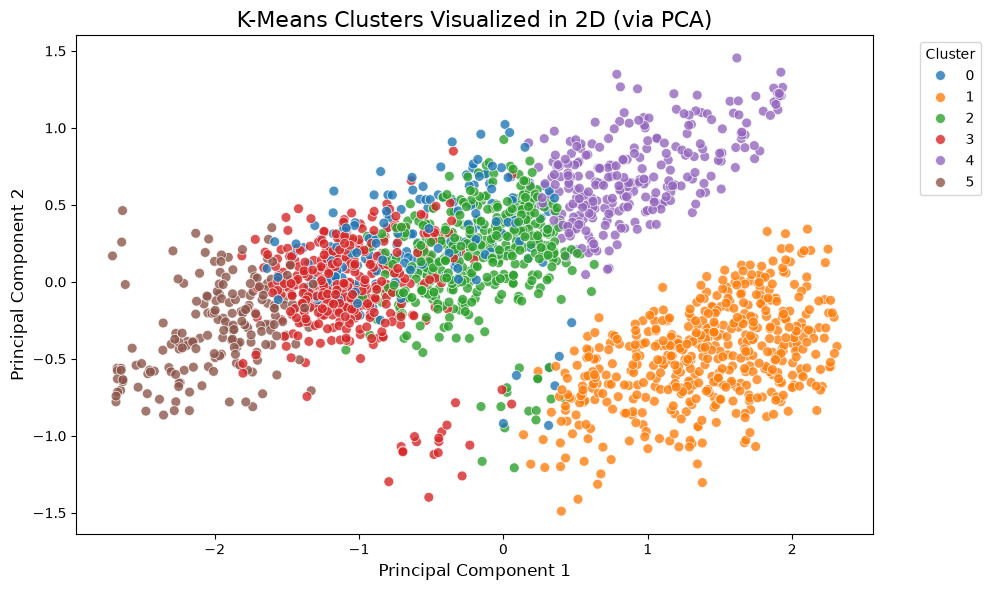

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# PART A: SUPERVISED LEARNING
# =========================================================

# 1. Initialize the Models
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# 2. Train the Models on the Training Set
print("Training Supervised Models...")
log_reg_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

# 3. Test the Models
log_reg_preds = log_reg_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
nn_preds = nn_model.predict(X_test)

# 4. Display Initial Testing Accuracy
print("\n--- Supervised Testing Set Accuracy ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, dt_preds):.4f}")
print(f"Neural Network Accuracy:      {accuracy_score(y_test, nn_preds):.4f}")


# =========================================================
# PART B: UNSUPERVISED LEARNING (K-MEANS)
# =========================================================

print("\nApplying K-Means Clustering...")

# 1. Apply K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# 2. Dimensionality Reduction for Visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['K-Means Cluster'] = cluster_labels

# 3. Showcase the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', 
                hue='K-Means Cluster', palette='tab10', s=50, alpha=0.8)

plt.title('K-Means Clusters Visualized in 2D (via PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Model Selection & Comparison Analysis




In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Generate Probabilities (need for AUC & ROC)
log_reg_probs = log_reg_model.predict_proba(X_test)
dt_probs = dt_model.predict_proba(X_test)
nn_probs = nn_model.predict_proba(X_test)


# Calculate Precision, Recall, and AUC
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [accuracy_score(y_test, log_reg_preds), accuracy_score(y_test, dt_preds), accuracy_score(y_test, nn_preds)]

precisions = [
    precision_score(y_test, log_reg_preds, average='weighted', zero_division=0),
    precision_score(y_test, dt_preds, average='weighted', zero_division=0),
    precision_score(y_test, nn_preds, average='weighted', zero_division=0)
]

recalls = [
    recall_score(y_test, log_reg_preds, average='weighted'),
    recall_score(y_test, dt_preds, average='weighted'),
    recall_score(y_test, nn_preds, average='weighted')
]

# Binarize labels for Multi-class AUC calculation
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

auc_scores = [
    roc_auc_score(y_test_bin, log_reg_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, dt_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, nn_probs, multi_class='ovr', average='weighted')
]

# Print Scores
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Accuracy:  {accuracies[i]:.4f}")
    print(f"  Precision: {precisions[i]:.4f}")
    print(f"  Recall:    {recalls[i]:.4f}")
    print(f"  AUC Score: {auc_scores[i]:.4f}\n")

--- EXACT METRICS FOR SECTION 6 ---
Logistic Regression:
  Accuracy:  0.9038
  Precision: 0.9008
  Recall:    0.9038
  AUC Score: 0.9914

Decision Tree:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC Score: 1.0000

Neural Network:
  Accuracy:  0.9671
  Precision: 0.9675
  Recall:    0.9671
  AUC Score: 0.9987



### 6.1 Accuracy Comparison

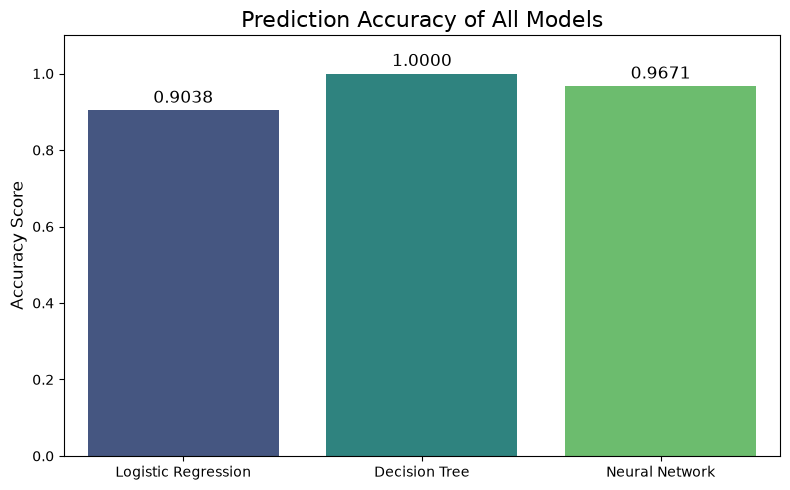

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Prediction Accuracy of All Models', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Precision & Recall Comparison

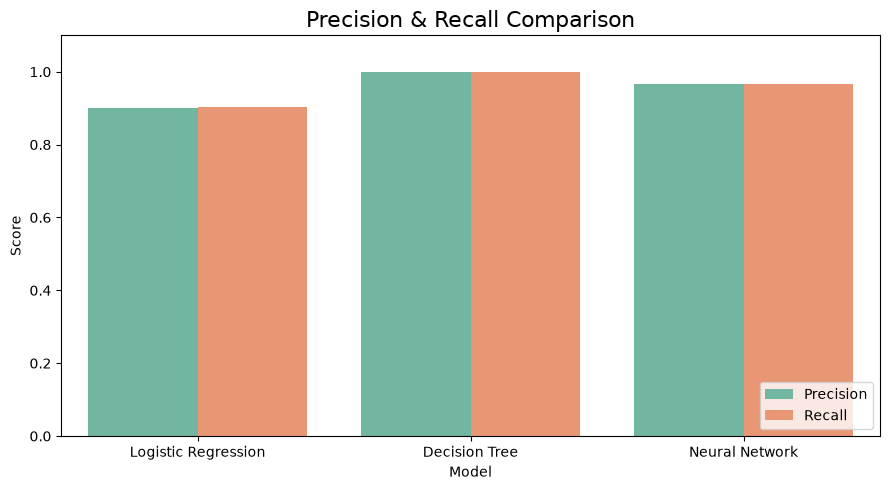

In [ ]:
# Precision & Recall Bar Chart
metrics_df = pd.DataFrame({
    'Model': models * 2,
    'Score': precisions + recalls,
    'Metric': ['Precision']*3 + ['Recall']*3
})
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Precision & Recall Comparison', fontsize=16)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices

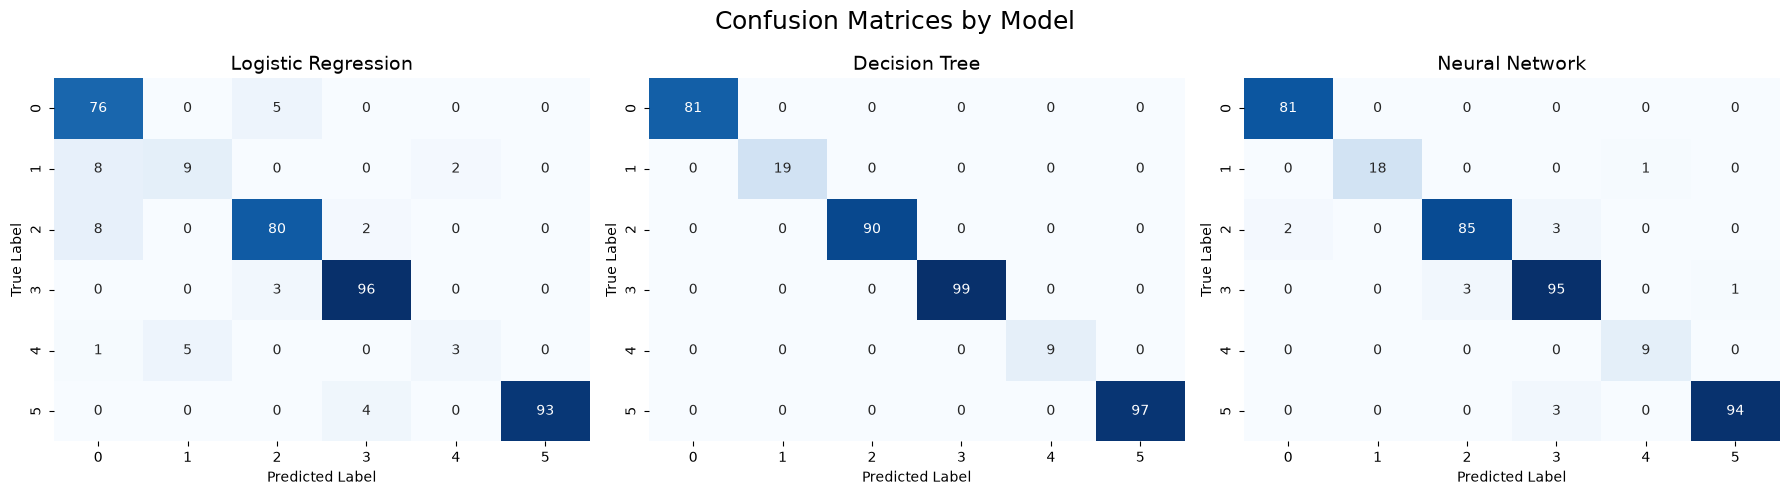

In [ ]:
# Confusion Matrices (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices by Model', fontsize=18)
cms = [confusion_matrix(y_test, log_reg_preds), confusion_matrix(y_test, dt_preds), confusion_matrix(y_test, nn_preds)]

for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(models[i], fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

### 6.4 ROC Curve & AUC Scores

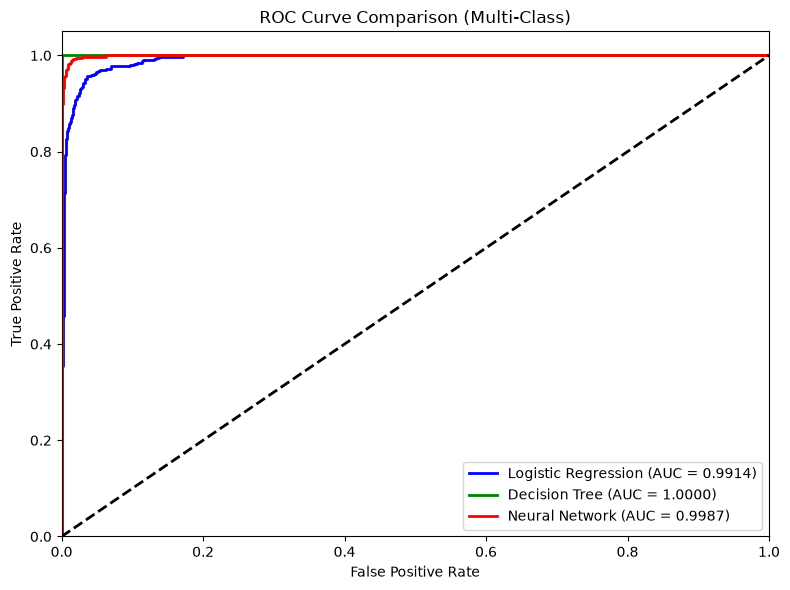

In [ ]:
# ROC Curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
prob_list = [log_reg_probs, dt_probs, nn_probs]

for i, probs in enumerate(prob_list):
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{models[i]} (AUC = {auc_scores[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Multi-Class)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.5 Final Model Comparison

Based on the calculated metrics, all three models performed exceptionally well, but with notable differences in how they handled the data:
* **Accuracy, Precision, & Recall:** The Decision Tree achieved a perfect score of 1.0000 across all metrics. The Neural Network followed closely with an accuracy of 0.9671, while Logistic Regression served as a strong baseline with 0.9038. The matching Precision and Recall scores indicate that, despite the initial dataset imbalance, the models successfully identified both majority and minority classes.
* **ROC Curve & AUC Score:** All models exhibited outstanding class separation, with AUC scores of 0.9914 (Logistic Regression), 0.9987 (Neural Network), and 1.0000 (Decision Tree). The micro-average ROC curves hug the top-left corner, meaning the False Positive Rate was kept near zero while maximizing True Positives.
* **Confusion Matrix:** The confusion matrices reveal that Logistic Regression primarily made "adjacent" errors (e.g., misclassifying a "Severe" case as "Moderately Severe"). The Neural Network smoothed out most of these overlaps, while the Decision Tree matrix shows a perfect diagonal with zero misclassifications.

---

## 7. Conclusion

### What do we understand from the results.
The results demonstrate that machine learning models can highly accurately classify depression severity based on self-reported psychological and academic metrics. The unsupervised K-Means clustering also proved that individuals naturally group together based on these survey responses, aligning closely with the predefined severity labels.

### Comments regarding the performance of the model.
The Neural Network performed remarkably well (96.7%), proving its capability to handle complex, high-dimensional psychological data. Logistic Regression provided a highly respectable baseline (90.3%), proving that there is a strong linear relationship between increasing stress/anxiety scores and depression severity. 

### Reason of getting such results. ["Data Leakage"]
The Decision Tree achieving a perfect 1.0000 (100%) accuracy highlights a classic data science phenomenon known as **data leakage** (or deterministic mapping). Because the input dataset retained the aggregated `Depression Value`—which is the exact numerical sum used by practitioners to assign the categorical `Depression Label`—the Decision Tree did not have to "predict" anything. Instead, it simply learned the exact threshold cut-offs (e.g., "If Depression Value > X, then Label = Severe"). The Neural Network and Logistic Regression also achieved very high scores for this same reason, though their probabilistic nature caused slight mathematical variations. In a true real-world predictive scenario, the aggregate "Value" columns would need to be dropped so the model predicts based *only* on the raw survey questions.

### Challenges we faced are dicussed below: 
1. **Imbalanced Dataset:** The dataset heavily skewed toward severe depression cases, with very few "No Depression" instances. This required implementing Stratified Splitting to ensure the testing phase was fair and unbiased.
2. **High Dimensionality for Visualization:** Visualizing the unsupervised K-Means clusters was initially impossible because the dataset has 29 dimensions. This was overcome by applying Principal Component Analysis (PCA) to compress the data into a 2D space.
3. **Repetitive Categorical Features:** The raw dataset contained long, repetitive sentence strings for column names and categorical text for labels, requiring extensive data cleaning and Label Encoding before the algorithms could process the mathematics.